# Salmonella AMR 2025 - Hướng A

Notebook này chạy tiếp sau kết quả Hướng A.

Phần phân tích AMP mở rộng **không còn cộng bộ đếm đặc trưng vào bảng ổn định chung của 5 thuốc**, nên `selected_frequency` sẽ nằm trong khoảng 0–1.

Notebook làm các việc chính:

1. Clone GitHub của bài báo 2025.
2. Thống kê dữ liệu theo 5 thuốc.
3. Chạy Hướng A lặp nhiều lần:
   - dùng 50 đặc trưng có sẵn của bài báo;
   - chọn lại đặc trưng chỉ trên tập huấn luyện từ ma trận gen phụ đầy đủ.
4. Phân tích riêng AMP với nhiều số lượng đặc trưng.
5. Tính đúng tần suất đặc trưng ổn định cho thí nghiệm chính.
6. Xuất bảng, biểu đồ và file nén kết quả.


In [ ]:
!pip -q install xgboost openpyxl

import os
import re
import json
import math
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from IPython.display import display, Markdown

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception as e:
    print("Không import được xgboost:", e)
    HAS_XGB = False

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

BASE_DIR = Path("/content/salmonella_amr_2025_directionA")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
OUT_DIR = Path("/content/salmonella_directionA_outputs_amp_stability")
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR:", OUT_DIR)


BASE_DIR: /content/salmonella_amr_2025_directionA
OUT_DIR: /content/salmonella_directionA_outputs_amp_stability


In [ ]:
repo_url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"

if not REPO_DIR.exists():
    !git clone --depth 1 {repo_url} {REPO_DIR}
else:
    print("Repo đã tồn tại:", REPO_DIR)

print("\nCác thư mục chính:")
!find {REPO_DIR} -maxdepth 2 -type d | head -50


Repo đã tồn tại: /content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella

Các thư mục chính:
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/.git
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/.git/branches
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/.git/info
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/.git/refs
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/.git/objects
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/.git/hooks
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/.git/logs
/content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-S

In [17]:
# ===================================
# 2. Giải nén các file .rar nếu cần
# ===================================

!apt-get update -qq
!apt-get install -y -qq unrar > /dev/null

EXTRACT_DIR = BASE_DIR / "extracted"
ACCESSORY_DIR = EXTRACT_DIR / "accessory_gene"
GPA_DIR = EXTRACT_DIR / "gene_presence_absence"
CORE_SNP_DIR = EXTRACT_DIR / "core_snp"

for d in [ACCESSORY_DIR, GPA_DIR, CORE_SNP_DIR]:
    d.mkdir(parents=True, exist_ok=True)

rar_files = {
    "accessory": REPO_DIR / "results" / "Roary" / "accessory gene existence matrix.rar",
    "gene_presence_absence": REPO_DIR / "results" / "Roary" / "gene_presence_absence.rar",
    "core_snp": REPO_DIR / "results" / "MAFFT" / "coreSNP.rar",
}

def extract_rar_if_needed(rar_path, out_dir):
    if not rar_path.exists():
        print("Không thấy file:", rar_path)
        return
    already = [p for p in out_dir.rglob("*") if p.is_file()]
    if already:
        print("Đã có file trong", out_dir, "-> bỏ qua giải nén")
        return
    print("Giải nén:", rar_path)
    !unrar x -o+ "{rar_path}" "{out_dir}/" > /dev/null

extract_rar_if_needed(rar_files["accessory"], ACCESSORY_DIR)
extract_rar_if_needed(rar_files["gene_presence_absence"], GPA_DIR)
extract_rar_if_needed(rar_files["core_snp"], CORE_SNP_DIR)

print("\nFile đã giải nén:")
!find {EXTRACT_DIR} -maxdepth 3 -type f | head -30


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Đã có file trong /content/salmonella_amr_2025_directionA/extracted/accessory_gene -> bỏ qua giải nén
Đã có file trong /content/salmonella_amr_2025_directionA/extracted/gene_presence_absence -> bỏ qua giải nén
Không thấy file: /content/salmonella_amr_2025_directionA/Antimicrobial-resistance-prediction-in-Salmonella/results/MAFFT/coreSNP.rar

File đã giải nén:
/content/salmonella_amr_2025_directionA/extracted/accessory_gene/accessory gene existence matrix.csv
/content/salmonella_amr_2025_directionA/extracted/gene_presence_absence/gene_presence_absence.Rtab


In [ ]:
# 3. Hàm đọc dữ liệu 

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

def read_table_flexible(path):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in [".tsv", ".txt"]:
        try:
            return pd.read_csv(path, sep=None, engine="python")
        except Exception:
            return pd.read_csv(path, sep="\t")
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    raise ValueError(f"Không hỗ trợ định dạng: {path}")

def find_largest_table(root):
    root = Path(root)
    candidates = []
    for suffix in [".csv", ".tsv", ".txt", ".xlsx", ".xls"]:
        candidates.extend(root.rglob(f"*{suffix}"))
    candidates = [p for p in candidates if p.is_file()]
    if not candidates:
        return None
    candidates = sorted(candidates, key=lambda p: p.stat().st_size, reverse=True)
    print("Các bảng tìm thấy trong", root)
    for p in candidates[:10]:
        print(" -", p.name, f"{p.stat().st_size/1024/1024:.2f} MB")
    return candidates[0]

def clean_binary_matrix(df):
    # Đưa ma trận đặc trưng về dạng số.
    df = df.copy()
    drop_cols = [c for c in df.columns if str(c).startswith("Unnamed")]
    if drop_cols:
        df = df.drop(columns=drop_cols)

    for col in list(df.columns):
        if df[col].dtype == "object":
            low_vals = set(df[col].dropna().astype(str).str.lower().unique()[:20])
            if low_vals.issubset({"0", "1", "true", "false", "yes", "no", "t", "f"}):
                df[col] = df[col].astype(str).str.lower().map({
                    "0":0, "1":1, "true":1, "false":0, "yes":1, "no":0, "t":1, "f":0
                })
            else:
                converted = pd.to_numeric(df[col], errors="coerce")
                if converted.notna().mean() > 0.95:
                    df[col] = converted.fillna(0)
                else:
                    df = df.drop(columns=[col])
    df = df.fillna(0)

    for col in df.columns:
        if df[col].min() < 0:
            df[col] = df[col] - df[col].min()
    return df

def load_ready_drug(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    X_path = drug_dir / "gene.csv"
    y_path = drug_dir / f"{drug}_label.csv"
    if not X_path.exists() or not y_path.exists():
        raise FileNotFoundError(f"Thiếu file cho {drug}: {drug_dir}")

    X = pd.read_csv(X_path)
    y_df = pd.read_csv(y_path)

    if y_df.shape[1] == 1:
        y = y_df.iloc[:, 0]
    else:
        possible = [c for c in y_df.columns if "label" in c.lower() or drug.lower() in c.lower()]
        y = y_df[possible[0]] if possible else y_df.iloc[:, -1]

    y = y.replace({"S":0, "I":0, "R":1, "s":0, "i":0, "r":1}).astype(int)
    X = clean_binary_matrix(X)
    X.index = range(len(X))
    y.index = range(len(y))
    return X, y

def load_accessory_full():
    table = find_largest_table(ACCESSORY_DIR)
    if table is None:
        raise FileNotFoundError("Không tìm thấy accessory gene existence matrix")
    df = read_table_flexible(table)
    print("Accessory raw shape:", df.shape)
    df = clean_binary_matrix(df)
    print("Accessory numeric shape:", df.shape)
    df.index = range(len(df))
    return df, table

X_full_accessory, accessory_path = load_accessory_full()
print("Full accessory:", X_full_accessory.shape)


Các bảng tìm thấy trong /content/salmonella_amr_2025_directionA/extracted/accessory_gene
 - accessory gene existence matrix.csv 40.59 MB
Accessory raw shape: (1167, 18126)
Accessory numeric shape: (1167, 18125)
Full accessory: (1167, 18125)


,drug,n_samples,n_ready_features,n_resistant,n_non_resistant,resistant_percent
0,AMP,1167,50,199,968,17.052271
1,AUG,1167,50,139,1028,11.910883
2,AXO,1167,50,71,1096,6.083976
3,CHL,1167,50,126,1041,10.796915
4,FOX,1167,50,71,1096,6.083976


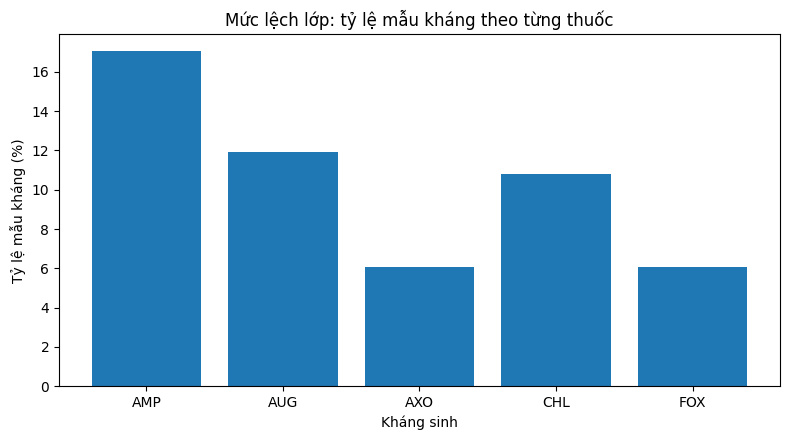

In [ ]:
# 4. Thống kê dataset theo 5 thuốc

dataset_rows = []
for drug in DRUGS:
    X_ready, y = load_ready_drug(drug)
    dataset_rows.append({
        "drug": drug,
        "n_samples": len(y),
        "n_ready_features": X_ready.shape[1],
        "n_resistant": int(y.sum()),
        "n_non_resistant": int((y == 0).sum()),
        "resistant_percent": 100 * float(y.mean())
    })

dataset_stats = pd.DataFrame(dataset_rows)
display(dataset_stats)
dataset_stats.to_csv(OUT_DIR / "dataset_stats.csv", index=False)

plt.figure(figsize=(8, 4.5))
plt.bar(dataset_stats["drug"], dataset_stats["resistant_percent"])
plt.ylabel("Tỷ lệ mẫu kháng (%)")
plt.xlabel("Kháng sinh")
plt.title("Mức lệch lớp: tỷ lệ mẫu kháng theo từng thuốc")
plt.tight_layout()
plt.savefig(OUT_DIR / "class_imbalance_by_drug.png", dpi=200)
plt.show()


In [ ]:
# 5. Hàm đánh giá mô hình

def get_model(model_name, random_state=42):
    if model_name == "LR":
        return LogisticRegression(max_iter=10000, class_weight="balanced", solver="lbfgs")
    if model_name == "RF":
        return RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=random_state,
            n_jobs=-1
        )
    if model_name == "XGB":
        if not HAS_XGB:
            raise RuntimeError("Không có xgboost")
        return xgb.XGBClassifier(
            n_estimators=300,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=-1
        )
    raise ValueError(model_name)

def metric_dict(y_true, pred, prob):
    out = {
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "auroc": np.nan,
        "auprc": np.nan,
    }
    if len(np.unique(y_true)) == 2:
        out["auroc"] = roc_auc_score(y_true, prob)
        out["auprc"] = average_precision_score(y_true, prob)
    return out

def fit_eval_model(X_train, X_test, y_train, y_test, model_name="LR", random_state=42):
    model = get_model(model_name, random_state=random_state)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
    else:
        prob = pred
    m = metric_dict(y_test, pred, prob)
    return m, model

def select_chi2_train_only(X_train, y_train, X_test, k):
    k = min(k, X_train.shape[1])
    selector = SelectKBest(score_func=chi2, k=k)
    X_train_sel = selector.fit_transform(X_train, y_train)
    X_test_sel = selector.transform(X_test)
    selected_names = list(X_train.columns[selector.get_support()])
    return X_train_sel, X_test_sel, selected_names, selector

def repeated_experiment_for_drug(
    drug,
    seeds=range(10),
    k_list=(50, 200),
    models=("LR", "XGB"),
    test_size=0.2
):
    X_ready, y = load_ready_drug(drug)
    X_full = X_full_accessory.copy()

    n = min(len(y), len(X_full), len(X_ready))
    y = y.iloc[:n].reset_index(drop=True)
    X_ready = X_ready.iloc[:n].reset_index(drop=True)
    X_full = X_full.iloc[:n].reset_index(drop=True)

    rows = []
    selected_counter = defaultdict(Counter)

    for seed in seeds:
        train_idx, test_idx = train_test_split(
            np.arange(n),
            test_size=test_size,
            random_state=seed,
            stratify=y
        )
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        # Setting 1: ready 50 features from paper
        Xr_train = X_ready.iloc[train_idx]
        Xr_test = X_ready.iloc[test_idx]
        for model_name in models:
            if model_name == "XGB" and not HAS_XGB:
                continue
            m, _ = fit_eval_model(Xr_train, Xr_test, y_train, y_test, model_name=model_name, random_state=seed)
            rows.append({
                "drug": drug,
                "seed": seed,
                "setting": "ready_50_features_from_paper",
                "model": model_name,
                "k_features": X_ready.shape[1],
                **m
            })

        # Setting 2/3: train-only chi2 selection from full accessory
        Xf_train = X_full.iloc[train_idx]
        Xf_test = X_full.iloc[test_idx]

        for k in k_list:
            X_train_sel, X_test_sel, selected_names, _ = select_chi2_train_only(
                Xf_train, y_train, Xf_test, k=k
            )
            setting = f"train_only_chi2_select_{k}_from_full_accessory"
            selected_counter[(drug, setting)].update(selected_names)

            for model_name in models:
                if model_name == "XGB" and not HAS_XGB:
                    continue
                m, _ = fit_eval_model(X_train_sel, X_test_sel, y_train, y_test, model_name=model_name, random_state=seed)
                rows.append({
                    "drug": drug,
                    "seed": seed,
                    "setting": setting,
                    "model": model_name,
                    "k_features": k,
                    **m
                })

    return pd.DataFrame(rows), selected_counter

def summarize_results(df):
    metrics = ["balanced_accuracy", "f1", "auroc", "auprc"]
    summary = (
        df.groupby(["drug", "setting", "model", "k_features"])[metrics]
        .agg(["mean", "std"])
        .reset_index()
    )
    summary.columns = ["_".join([c for c in col if c]) for col in summary.columns.to_flat_index()]
    return summary


In [ ]:
# 6. Chạy Hướng A lặp nhiều lần cho 5 thuốc

N_REPEATS = 10
SEEDS = list(range(100, 100 + N_REPEATS))

K_LIST = (50, 200)
MODELS = ("LR", "XGB")

all_rows = []
global_selected_counter = defaultdict(Counter)

for drug in DRUGS:
    print("\n" + "="*80)
    print("Đang chạy:", drug)
    df_drug, counter_drug = repeated_experiment_for_drug(
        drug=drug,
        seeds=SEEDS,
        k_list=K_LIST,
        models=MODELS,
        test_size=0.2
    )
    all_rows.append(df_drug)
    for key, cnt in counter_drug.items():
        global_selected_counter[key].update(cnt)

directionA_results = pd.concat(all_rows, ignore_index=True)
directionA_summary = summarize_results(directionA_results)

display(directionA_results.head())
display(directionA_summary)

directionA_results.to_csv(OUT_DIR / "directionA_repeated_raw_results.csv", index=False)
directionA_summary.to_csv(OUT_DIR / "directionA_repeated_summary.csv", index=False)
print("Đã lưu kết quả vào:", OUT_DIR)



Đang chạy: AMP

Đang chạy: AUG

Đang chạy: AXO

Đang chạy: CHL

Đang chạy: FOX


,drug,seed,setting,model,k_features,accuracy,balanced_accuracy,f1,auroc,auprc
0,AMP,100,ready_50_features_from_paper,LR,50,0.970085,0.962113,0.915663,0.989433,0.969810
1,AMP,100,ready_50_features_from_paper,XGB,50,0.978632,0.957345,0.936709,0.979446,0.948526
2,AMP,100,train_only_chi2_select_50_from_full_accessory,LR,50,0.858974,0.865335,0.679612,0.913531,0.807754
3,AMP,100,train_only_chi2_select_50_from_full_accessory,XGB,50,0.931624,0.839691,0.777778,0.906701,0.764320
4,AMP,100,train_only_chi2_select_200_from_full_accessory,LR,200,0.952991,0.941881,0.870588,0.977513,0.940510


,drug,setting,model,k_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
0,AMP,ready_50_features_from_paper,LR,50,0.955464,0.010112,0.919714,0.012785,0.977229,0.011419,0.953559,0.016399
1,AMP,ready_50_features_from_paper,XGB,50,0.948892,0.018388,0.932918,0.025080,0.978299,0.010114,0.948128,0.015637
2,AMP,train_only_chi2_select_200_from_full_accessory,LR,200,0.925052,0.017890,0.869727,0.023794,0.941534,0.024045,0.898239,0.033295
3,AMP,train_only_chi2_select_200_from_full_accessory,XGB,200,0.916791,0.024570,0.884745,0.028860,0.950013,0.015400,0.908351,0.020719
4,AMP,train_only_chi2_select_50_from_full_accessory,LR,50,0.858827,0.027214,0.718741,0.050848,0.900857,0.033632,0.803403,0.060767
5,AMP,train_only_chi2_select_50_from_full_accessory,XGB,50,0.846830,0.027279,0.800355,0.037868,0.898421,0.032116,0.797222,0.060837
6,AUG,ready_50_features_from_paper,LR,50,0.977618,0.012800,0.939736,0.024564,0.984787,0.010869,0.930892,0.041235
7,AUG,ready_50_features_from_paper,XGB,50,0.968117,0.014165,0.936763,0.023476,0.981068,0.014488,0.955304,0.033183
8,AUG,train_only_chi2_select_200_from_full_accessory,LR,200,0.980947,0.010670,0.941899,0.022650,0.986503,0.011031,0.952208,0.027992
9,AUG,train_only_chi2_select_200_from_full_accessory,XGB,200,0.968360,0.021909,0.938176,0.029735,0.985376,0.011040,0.944689,0.035347


Đã lưu kết quả vào: /content/salmonella_directionA_outputs_amp_stability


## Thiết lập tốt nhất theo từng thuốc

,drug,setting,model,k_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
0,AMP,ready_50_features_from_paper,LR,50,0.955464,0.010112,0.919714,0.012785,0.977229,0.011419,0.953559,0.016399
1,AUG,train_only_chi2_select_200_from_full_accessory,LR,200,0.980947,0.010670,0.941899,0.022650,0.986503,0.011031,0.952208,0.027992
2,AXO,ready_50_features_from_paper,LR,50,0.981688,0.018847,0.974594,0.024321,0.999578,0.000632,0.994751,0.007209
3,CHL,train_only_chi2_select_200_from_full_accessory,LR,200,0.924019,0.022959,0.878031,0.037215,0.936785,0.025258,0.898048,0.035308
4,FOX,train_only_chi2_select_200_from_full_accessory,LR,200,0.974773,0.029196,0.970056,0.030133,0.974740,0.029653,0.952076,0.054358


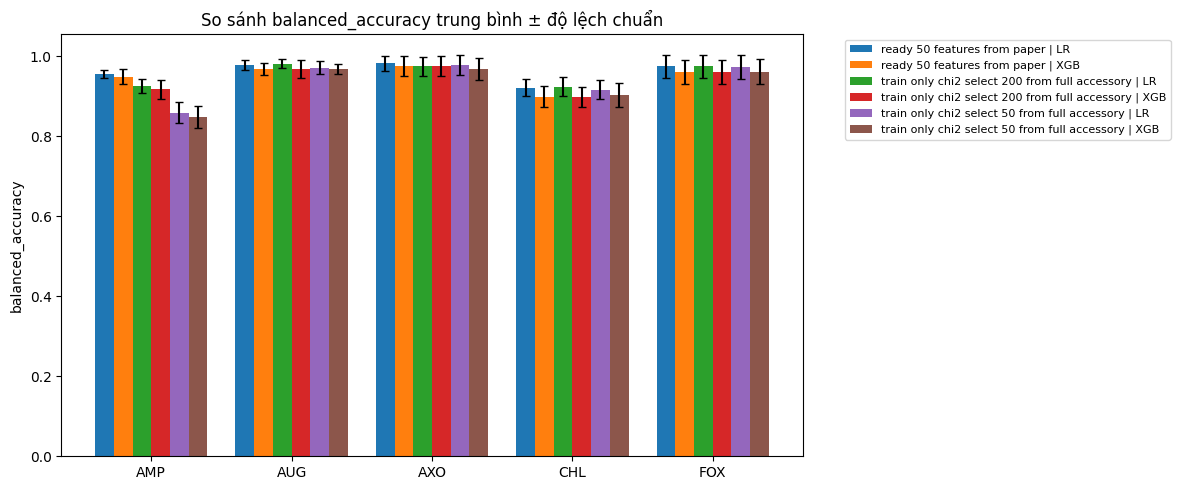

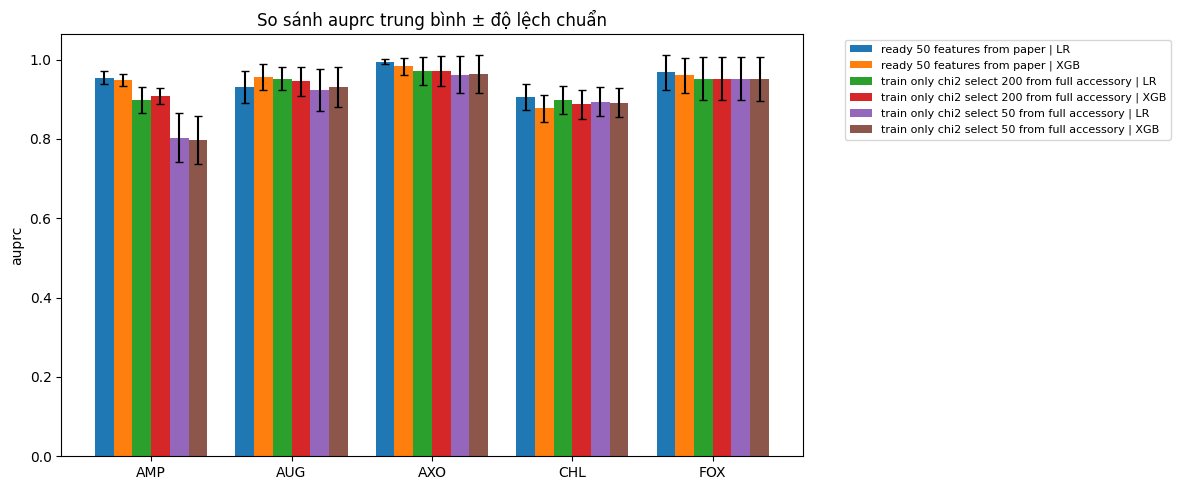

In [ ]:
# 7. Bảng tốt nhất theo từng thuốc + hình so sánh

summary_simple = directionA_summary.copy()
summary_simple = summary_simple.sort_values(
    ["drug", "balanced_accuracy_mean", "auprc_mean"],
    ascending=[True, False, False]
)

best_per_drug = summary_simple.groupby("drug").head(1).reset_index(drop=True)

display(Markdown("## Thiết lập tốt nhất theo từng thuốc"))
display(best_per_drug[[
    "drug", "setting", "model", "k_features",
    "balanced_accuracy_mean", "balanced_accuracy_std",
    "f1_mean", "f1_std",
    "auroc_mean", "auroc_std",
    "auprc_mean", "auprc_std"
]])

best_per_drug.to_csv(OUT_DIR / "best_setting_per_drug.csv", index=False)

plot_df = directionA_summary.copy()
plot_df["label"] = plot_df["setting"].str.replace("_", " ") + " | " + plot_df["model"]

for metric in ["balanced_accuracy", "auprc"]:
    plt.figure(figsize=(12, 5))
    drugs = DRUGS
    x = np.arange(len(drugs))
    labels = plot_df["label"].unique()
    width = 0.8 / len(labels)

    for i, label in enumerate(labels):
        vals = []
        errs = []
        for d in drugs:
            row = plot_df[(plot_df["drug"] == d) & (plot_df["label"] == label)]
            if len(row) == 0:
                vals.append(np.nan)
                errs.append(0)
            else:
                vals.append(float(row[f"{metric}_mean"].iloc[0]))
                errs.append(float(row[f"{metric}_std"].iloc[0]) if not np.isnan(row[f"{metric}_std"].iloc[0]) else 0)
        plt.bar(x + i*width - 0.4 + width/2, vals, width, yerr=errs, capsize=3, label=label)

    plt.xticks(x, drugs)
    plt.ylabel(metric)
    plt.title(f"So sánh {metric} trung bình ± độ lệch chuẩn")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"{metric}_comparison_repeated.png", dpi=200)
    plt.show()


Chạy phân tích AMP riêng với nhiều k: (50, 100, 200, 300, 500)


,drug,setting,model,k_features,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
0,AMP,ready_50_features_from_paper,LR,50,0.955464,0.010112,0.919714,0.012785,0.977229,0.011419,0.953559,0.016399
9,AMP,train_only_chi2_select_500_from_full_accessory,XGB,500,0.949626,0.016747,0.931853,0.019629,0.973151,0.012589,0.946283,0.020852
1,AMP,ready_50_features_from_paper,XGB,50,0.948892,0.018388,0.932918,0.025080,0.978299,0.010114,0.948128,0.015637
8,AMP,train_only_chi2_select_500_from_full_accessory,LR,500,0.948003,0.010628,0.916158,0.011350,0.970664,0.014332,0.946327,0.025516
6,AMP,train_only_chi2_select_300_from_full_accessory,LR,300,0.936456,0.017288,0.898817,0.027231,0.942165,0.035817,0.916149,0.034415
7,AMP,train_only_chi2_select_300_from_full_accessory,XGB,300,0.933299,0.020243,0.904956,0.028758,0.953028,0.022585,0.923239,0.027826
4,AMP,train_only_chi2_select_200_from_full_accessory,LR,200,0.925052,0.017890,0.869727,0.023794,0.941534,0.024045,0.898239,0.033295
5,AMP,train_only_chi2_select_200_from_full_accessory,XGB,200,0.916791,0.024570,0.884745,0.028860,0.950013,0.015400,0.908351,0.020719
2,AMP,train_only_chi2_select_100_from_full_accessory,LR,100,0.913686,0.028222,0.845121,0.040671,0.945812,0.019388,0.888788,0.036135
3,AMP,train_only_chi2_select_100_from_full_accessory,XGB,100,0.911791,0.031630,0.878332,0.035277,0.944085,0.022943,0.892734,0.031942


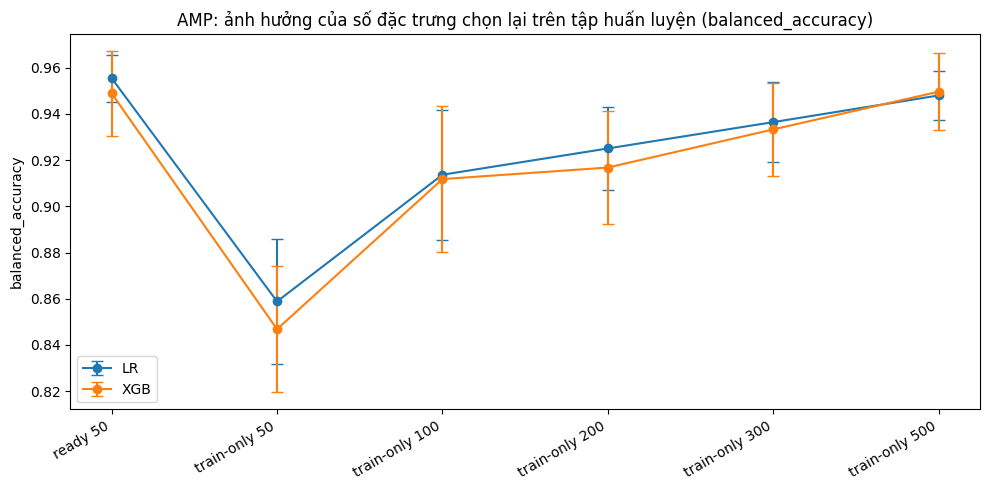

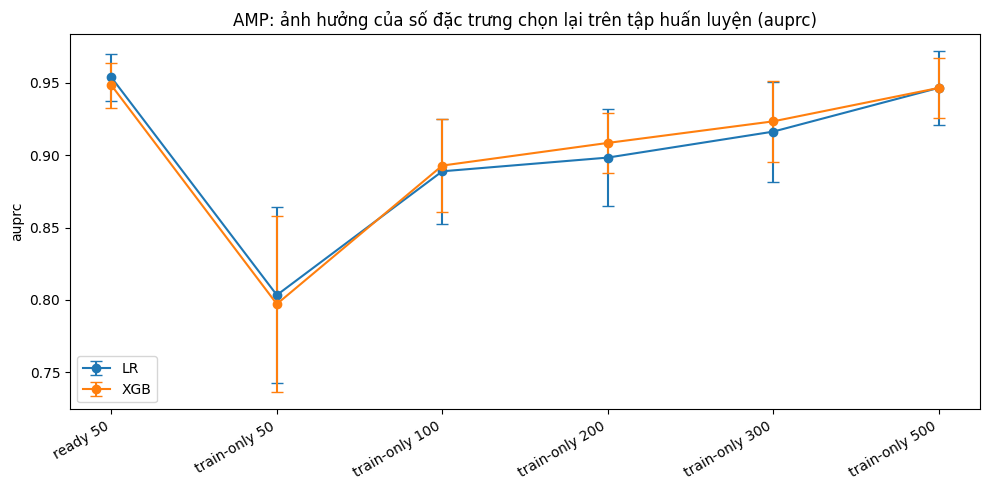

Đã lưu bộ đếm đặc trưng AMP riêng, chưa cộng vào bảng ổn định chung.


In [ ]:
# 8. Phân tích riêng AMP: tăng số đặc trưng chọn lại

AMP_K_LIST = (50, 100, 200, 300, 500)
AMP_MODELS = ("LR", "XGB")
AMP_SEEDS = SEEDS

print("Chạy phân tích AMP riêng với nhiều k:", AMP_K_LIST)
df_amp, counter_amp = repeated_experiment_for_drug(
    drug="AMP",
    seeds=AMP_SEEDS,
    k_list=AMP_K_LIST,
    models=AMP_MODELS,
    test_size=0.2
)

amp_results = df_amp
amp_summary = summarize_results(amp_results)

display(amp_summary.sort_values(["balanced_accuracy_mean", "auprc_mean"], ascending=False))

amp_results.to_csv(OUT_DIR / "AMP_k_sweep_raw_results.csv", index=False)
amp_summary.to_csv(OUT_DIR / "AMP_k_sweep_summary.csv", index=False)

amp_plot = amp_summary.copy()
amp_plot["k_label"] = amp_plot.apply(
    lambda r: "ready 50" if r["setting"] == "ready_50_features_from_paper" else f"train-only {int(r['k_features'])}",
    axis=1
)

for metric in ["balanced_accuracy", "auprc"]:
    plt.figure(figsize=(10, 5))
    for model_name in AMP_MODELS:
        sub = amp_plot[amp_plot["model"] == model_name].copy()
        order = ["ready 50"] + [f"train-only {k}" for k in AMP_K_LIST]
        sub["order"] = sub["k_label"].apply(lambda x: order.index(x) if x in order else 999)
        sub = sub.sort_values("order")
        plt.errorbar(
            sub["k_label"], sub[f"{metric}_mean"],
            yerr=sub[f"{metric}_std"], marker="o", capsize=4, label=model_name
        )
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.title(f"AMP: ảnh hưởng của số đặc trưng chọn lại trên tập huấn luyện ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"AMP_k_sweep_{metric}.png", dpi=200)
    plt.show()

# LƯU Ý QUAN TRỌNG:
# counter_amp chỉ dùng riêng cho phân tích AMP mở rộng.
# Không cộng counter_amp vào global_selected_counter, vì nếu cộng vào thì các đặc trưng AMP sẽ bị đếm hai lần
# và selected_frequency có thể > 1.

# Tạo bảng đặc trưng ổn định riêng cho AMP k-sweep.
def amp_counter_to_df(counter_dict, n_repeats, top_n=50):
    rows = []
    for (drug_name, setting_name), cnt in counter_dict.items():
        for feature, count in cnt.most_common(top_n):
            rows.append({
                "drug": drug_name,
                "setting": setting_name,
                "feature": feature,
                "selected_count": count,
                "selected_frequency": count / n_repeats,
                "annotation": annotate_feature(feature) if "annotate_feature" in globals() else ""
            })
    return pd.DataFrame(rows)

amp_stable_features_raw = amp_counter_to_df(counter_amp, n_repeats=len(AMP_SEEDS), top_n=50)
amp_stable_features_raw.to_csv(OUT_DIR / "AMP_k_sweep_stable_features_raw_before_annotation.csv", index=False)
print("Đã lưu bộ đếm đặc trưng AMP riêng, chưa cộng vào bảng ổn định chung.")



In [ ]:
# 9. Tạo bản đồ chú giải gene nếu có thể

manual_annotation = {
    "GXG79_15935": "Bacteriophage tail tape measure protein",
    "GXH02_05140": "Bacteriophage tail protein",
    "FKE51_24750": "C-class beta-lactamase CMY-2",
    "CKP39_24515": "A-class broad-spectrum beta-lactamase TEM-1",
    "GRX98_004990": "Recombinase family proteins",
    "EEK86_04735": "IS1380-like element ISEc9 family transposase",
    "snp581705": "SNP feature, no direct annotation in Table S3",
    "sugE": "Anti quaternary ammonium compound protein SugE",
    "merT": "Mercury transporter MerT",
    "merA": "Mercury(II) reductase",
    "HF382_003898": "Endonuclease",
    "HF382_002470": "Hypothetical/assumed protein",
    "HF382_003966": "LysR family transcriptional regulator",
    "floR": "Chloramphenicol/florfenicol efflux MFS transporter FloR",
    "GP118_004663": "DUF1367 family protein",
    "FER41_22475": "Transcriptional regulator",
    "CYN48_22375": "Hypothetical protein",
    "GY345_004353": "Adenosine phosphate reductase family protein",
}

def build_roary_annotation_map():
    table = find_largest_table(GPA_DIR)
    if table is None:
        print("Không tìm thấy gene_presence_absence table; dùng manual annotation.")
        return {}
    try:
        gpa = read_table_flexible(table)
    except Exception as e:
        print("Không đọc được gene_presence_absence:", e)
        return {}
    print("gene_presence_absence shape:", gpa.shape)
    print("Columns:", list(gpa.columns[:20]))

    ann_map = {}
    gene_col_candidates = [c for c in gpa.columns if c.lower() in ["gene", "gene name", "gene_name"]]
    annotation_candidates = [c for c in gpa.columns if "annotation" in c.lower()]
    nonunique_candidates = [c for c in gpa.columns if "non-unique" in c.lower() or "nonunique" in c.lower()]

    gene_col = gene_col_candidates[0] if gene_col_candidates else gpa.columns[0]
    ann_col = annotation_candidates[0] if annotation_candidates else None
    non_col = nonunique_candidates[0] if nonunique_candidates else None

    for _, row in gpa.iterrows():
        keys = []
        for c in [gene_col, non_col]:
            if c is not None and pd.notna(row.get(c, np.nan)):
                keys.append(str(row[c]))
        ann = ""
        if ann_col is not None and pd.notna(row.get(ann_col, np.nan)):
            ann = str(row[ann_col])
        for k in keys:
            if k and k != "nan":
                ann_map[k] = ann
    print("Số annotation map:", len(ann_map))
    return ann_map

roary_annotation = build_roary_annotation_map()

def annotate_feature(feature):
    f = str(feature).strip()
    if f in manual_annotation:
        return manual_annotation[f]
    if f in roary_annotation:
        return roary_annotation[f]
    return ""

print("Manual annotations:", len(manual_annotation))
print("Roary annotations:", len(roary_annotation))


Không tìm thấy gene_presence_absence table; dùng manual annotation.
Manual annotations: 18
Roary annotations: 0


Tần suất chọn đặc trưng lớn nhất: 1.0
OK: selected_frequency nằm trong khoảng 0–1.


,drug,setting,feature,selected_count,n_repeats_used,selected_frequency,annotation
0,AMP,train_only_chi2_select_50_from_full_accessory,HF382_002470,10,10,1.0,Hypothetical/assumed protein
1,AMP,train_only_chi2_select_50_from_full_accessory,GXH02_05140,10,10,1.0,Bacteriophage tail protein
2,AMP,train_only_chi2_select_50_from_full_accessory,CBU12_02120,10,10,1.0,
3,AMP,train_only_chi2_select_50_from_full_accessory,B5A41_24415,10,10,1.0,
4,AMP,train_only_chi2_select_50_from_full_accessory,C3004_19165,10,10,1.0,
5,AMP,train_only_chi2_select_50_from_full_accessory,CGT24_24070,10,10,1.0,
6,AMP,train_only_chi2_select_50_from_full_accessory,NIO22_003658,10,10,1.0,
7,AMP,train_only_chi2_select_50_from_full_accessory,C3009_23215,10,10,1.0,
8,AMP,train_only_chi2_select_50_from_full_accessory,CKP58_25195,10,10,1.0,
9,AMP,train_only_chi2_select_50_from_full_accessory,K3989_004263,10,10,1.0,


,drug,setting,feature,selected_count,n_repeats_used,selected_frequency,annotation
50,AMP,train_only_chi2_select_200_from_full_accessory,group_3068,10,10,1.0,
51,AMP,train_only_chi2_select_200_from_full_accessory,CJW30_15375,10,10,1.0,
52,AMP,train_only_chi2_select_200_from_full_accessory,HF382_002470,10,10,1.0,Hypothetical/assumed protein
53,AMP,train_only_chi2_select_200_from_full_accessory,GXH02_05140,10,10,1.0,Bacteriophage tail protein
54,AMP,train_only_chi2_select_200_from_full_accessory,DSP25_11545,10,10,1.0,
...,...,...,...,...,...,...,...
410,FOX,train_only_chi2_select_50_from_full_accessory,group_8256,10,10,1.0,
411,FOX,train_only_chi2_select_50_from_full_accessory,C4F01_23125,10,10,1.0,
412,FOX,train_only_chi2_select_50_from_full_accessory,GSD29_004597,10,10,1.0,
413,FOX,train_only_chi2_select_50_from_full_accessory,GXA66_17220,10,10,1.0,


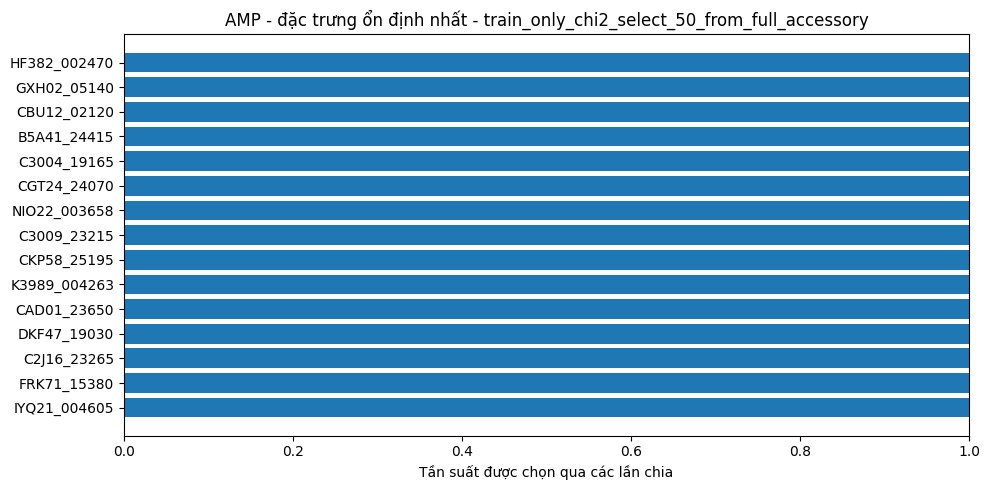

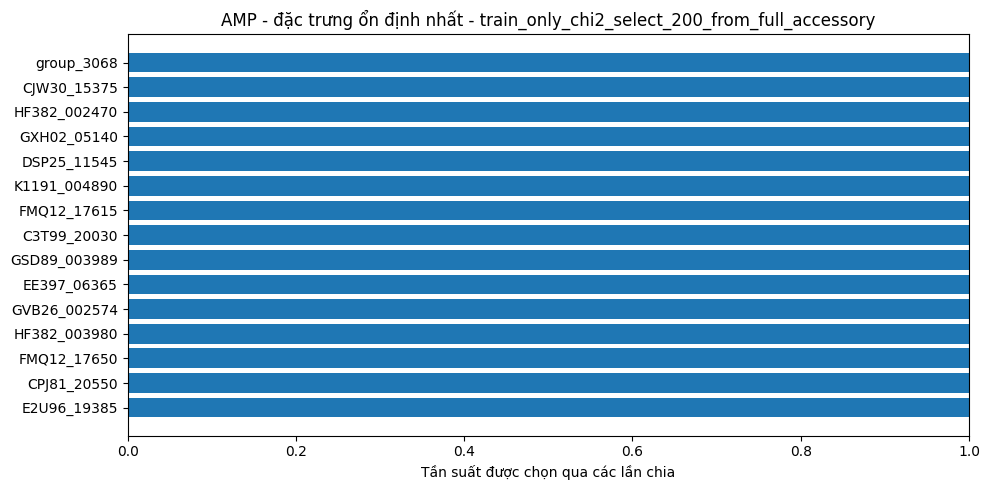

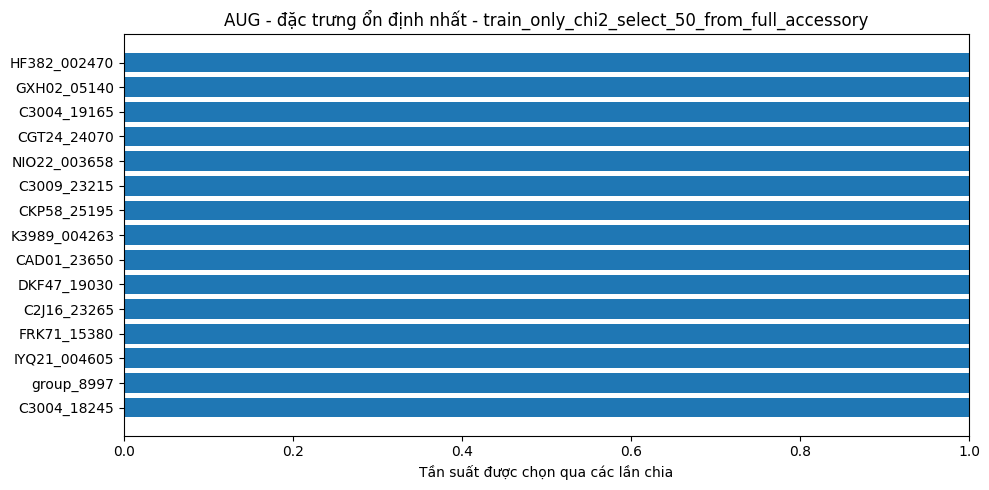

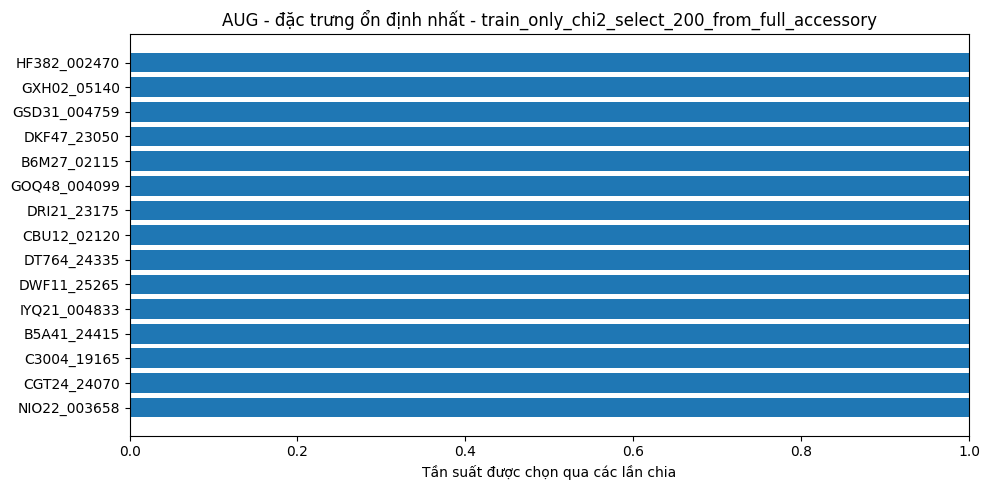

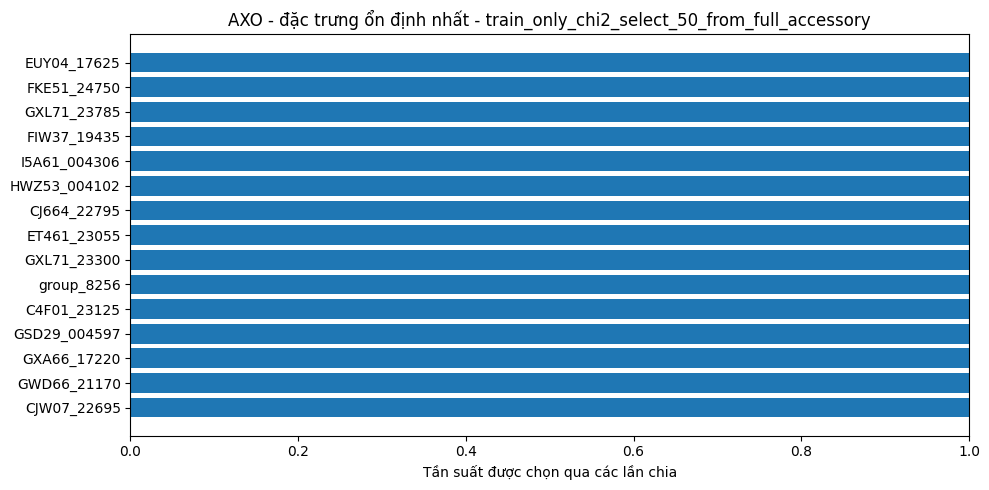

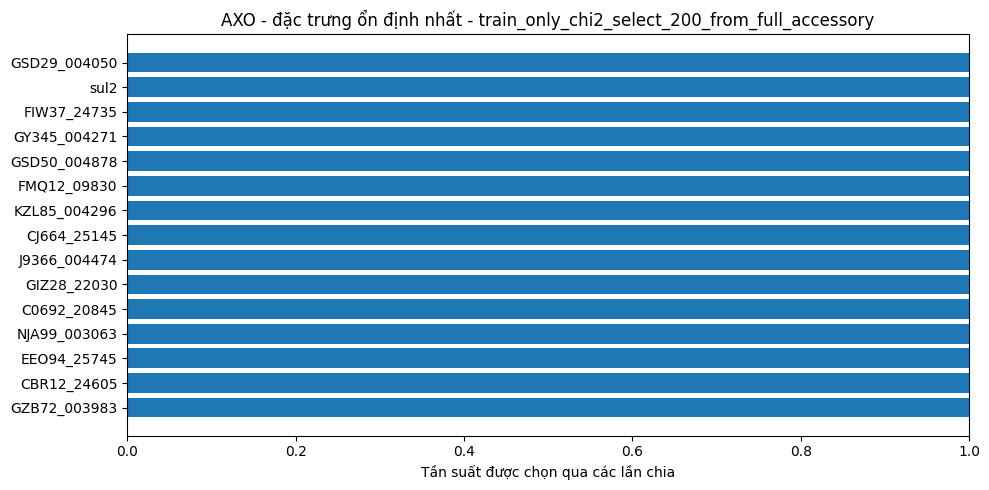

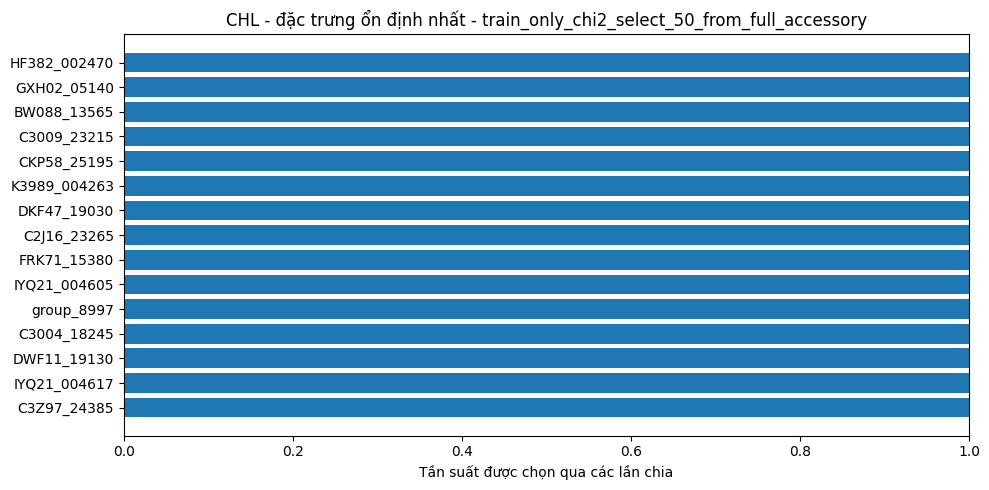

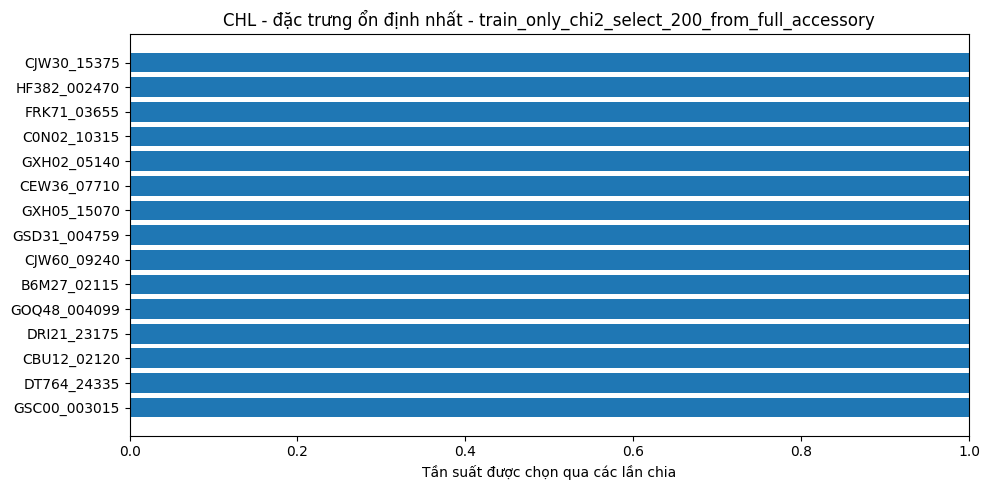

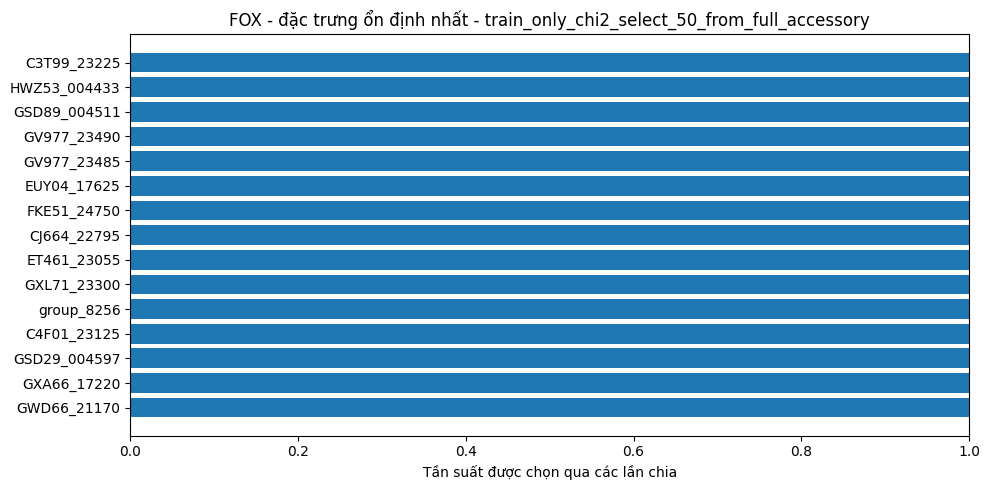

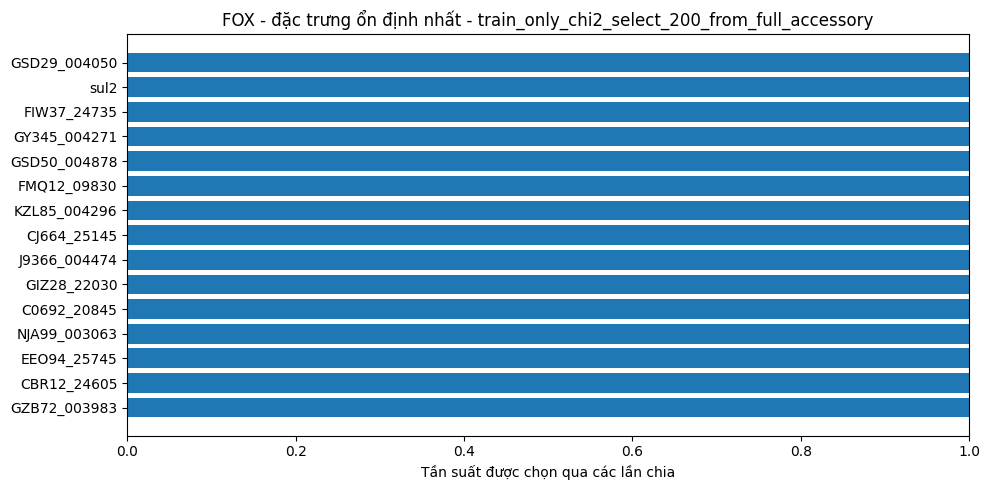

,drug,setting,feature,selected_count,n_repeats_used,selected_frequency,annotation
0,AMP,train_only_chi2_select_50_from_full_accessory,HF382_002470,10,10,1.0,Hypothetical/assumed protein
1,AMP,train_only_chi2_select_50_from_full_accessory,GXH02_05140,10,10,1.0,Bacteriophage tail protein
2,AMP,train_only_chi2_select_50_from_full_accessory,CBU12_02120,10,10,1.0,
3,AMP,train_only_chi2_select_50_from_full_accessory,B5A41_24415,10,10,1.0,
4,AMP,train_only_chi2_select_50_from_full_accessory,C3004_19165,10,10,1.0,
5,AMP,train_only_chi2_select_50_from_full_accessory,CGT24_24070,10,10,1.0,
6,AMP,train_only_chi2_select_50_from_full_accessory,NIO22_003658,10,10,1.0,
7,AMP,train_only_chi2_select_50_from_full_accessory,C3009_23215,10,10,1.0,
8,AMP,train_only_chi2_select_50_from_full_accessory,CKP58_25195,10,10,1.0,
9,AMP,train_only_chi2_select_50_from_full_accessory,K3989_004263,10,10,1.0,


Đã lưu bảng đặc trưng ổn định riêng cho AMP k-sweep: /content/salmonella_directionA_outputs_amp_stability/AMP_k_sweep_stable_features_FIXED.csv


In [ ]:
# 10. Thống kê đặc trưng ổn định - BẢN SỬA LỖI

# Bảng này chỉ dùng global_selected_counter từ thí nghiệm chính ở Cell 6.
# Không cộng thêm counter_amp của phân tích AMP mở rộng, để tránh đếm trùng AMP.
# Vì vậy selected_frequency = selected_count / N_REPEATS sẽ luôn nằm trong khoảng 0 đến 1.

def counter_to_df(counter, drug, setting, n_repeats, top_n=50):
    rows = []
    for feature, count in counter.most_common(top_n):
        rows.append({
            "drug": drug,
            "setting": setting,
            "feature": feature,
            "selected_count": count,
            "n_repeats_used": n_repeats,
            "selected_frequency": count / n_repeats,
            "annotation": annotate_feature(feature)
        })
    return pd.DataFrame(rows)

stable_tables = []
for (drug, setting), cnt in global_selected_counter.items():
    df_stable = counter_to_df(cnt, drug, setting, N_REPEATS, top_n=50)
    stable_tables.append(df_stable)

stable_features = pd.concat(stable_tables, ignore_index=True) if stable_tables else pd.DataFrame()

# Kiểm tra an toàn: tần suất không được > 1.
if len(stable_features) > 0:
    max_freq = stable_features["selected_frequency"].max()
    print("Tần suất chọn đặc trưng lớn nhất:", max_freq)
    if max_freq > 1.000001:
        print("CẢNH BÁO: selected_frequency > 1. Cần kiểm tra bộ đếm bị cộng trùng.")
    else:
        print("OK: selected_frequency nằm trong khoảng 0–1.")

display(stable_features.head(30))
stable_features.to_csv(OUT_DIR / "stable_selected_features_all_drugs_FIXED.csv", index=False)

# Tạo thêm bảng top 15 đặc trưng ổn định nhất cho mỗi thuốc/thiết lập.
top_stable_features = (
    stable_features
    .sort_values(["drug", "setting", "selected_frequency", "selected_count"], ascending=[True, True, False, False])
    .groupby(["drug", "setting"], as_index=False)
    .head(15)
)
top_stable_features.to_csv(OUT_DIR / "top15_stable_selected_features_all_drugs_FIXED.csv", index=False)
display(top_stable_features)

for drug in DRUGS:
    for setting in [
        "train_only_chi2_select_50_from_full_accessory",
        "train_only_chi2_select_200_from_full_accessory"
    ]:
        sub = stable_features[(stable_features["drug"] == drug) & (stable_features["setting"] == setting)].head(15)
        if len(sub) == 0:
            continue
        plt.figure(figsize=(10, 5))
        plt.barh(sub["feature"][::-1], sub["selected_frequency"][::-1])
        plt.xlim(0, 1.0)
        plt.xlabel("Tần suất được chọn qua các lần chia")
        plt.title(f"{drug} - đặc trưng ổn định nhất - {setting}")
        plt.tight_layout()
        safe_setting = setting.replace("/", "_")
        plt.savefig(OUT_DIR / f"stable_features_{drug}_{safe_setting}_FIXED.png", dpi=200)
        plt.show()

# Sau khi annotate_feature đã được định nghĩa, tạo lại bảng AMP k-sweep stability riêng có chú giải.
# Bảng này KHÔNG được dùng để tính overlap chính, chỉ dùng để xem riêng AMP.
amp_stable_tables = []
if "counter_amp" in globals():
    for (drug, setting), cnt in counter_amp.items():
        amp_stable_tables.append(counter_to_df(cnt, drug, setting, len(AMP_SEEDS), top_n=50))
    amp_stable_features = pd.concat(amp_stable_tables, ignore_index=True) if amp_stable_tables else pd.DataFrame()
    display(amp_stable_features.head(30))
    amp_stable_features.to_csv(OUT_DIR / "AMP_k_sweep_stable_features_FIXED.csv", index=False)
    print("Đã lưu bảng đặc trưng ổn định riêng cho AMP k-sweep:", OUT_DIR / "AMP_k_sweep_stable_features_FIXED.csv")


In [ ]:
# 11. So sánh overlap giữa 50 đặc trưng có sẵn và feature chọn lại

overlap_rows = []

for drug in DRUGS:
    X_ready, y = load_ready_drug(drug)
    ready_features = set(map(str, X_ready.columns))
    for setting in [
        "train_only_chi2_select_50_from_full_accessory",
        "train_only_chi2_select_200_from_full_accessory"
    ]:
        sub = stable_features[(stable_features["drug"] == drug) & (stable_features["setting"] == setting)]
        selected_features = set(sub["feature"].astype(str))
        inter = ready_features & selected_features
        union = ready_features | selected_features
        overlap_rows.append({
            "drug": drug,
            "setting": setting,
            "n_ready_features": len(ready_features),
            "n_stable_features_listed": len(selected_features),
            "n_overlap": len(inter),
            "jaccard": len(inter) / len(union) if union else np.nan,
            "overlap_features": "; ".join(sorted(inter)[:50])
        })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)
overlap_df.to_csv(OUT_DIR / "overlap_ready50_vs_train_only_features.csv", index=False)


,drug,setting,n_ready_features,n_stable_features_listed,n_overlap,jaccard,overlap_features
0,AMP,train_only_chi2_select_50_from_full_accessory,50,50,5,0.052632,FKE51_24750; GR980_004996; GXH02_05140; HF382_...
1,AMP,train_only_chi2_select_200_from_full_accessory,50,50,4,0.041667,CJW30_15375; GXH02_05140; HF382_002470; group_...
2,AUG,train_only_chi2_select_50_from_full_accessory,50,50,4,0.041667,EEK86_04735; FKE51_24750; GXH02_05140; HF382_0...
3,AUG,train_only_chi2_select_200_from_full_accessory,50,50,2,0.020408,GXH02_05140; HF382_002470
4,AXO,train_only_chi2_select_50_from_full_accessory,50,50,9,0.098901,CBR12_22525; CYN48_22375; E2U96_22865; FIW37_1...
5,AXO,train_only_chi2_select_200_from_full_accessory,50,50,7,0.075269,CYN48_22375; FIW37_19435; FKE51_24750; GSD29_0...
6,CHL,train_only_chi2_select_50_from_full_accessory,50,50,13,0.149425,C2484_25205; CAD01_24950; CJW30_15375; CPJ81_1...
7,CHL,train_only_chi2_select_200_from_full_accessory,50,50,3,0.030928,CJW30_15375; GXH02_05140; HF382_002470
8,FOX,train_only_chi2_select_50_from_full_accessory,50,50,4,0.041667,CYN48_22375; FKE51_24750; GY345_004353; group_...
9,FOX,train_only_chi2_select_200_from_full_accessory,50,50,7,0.075269,CYN48_22375; FIW37_19435; FKE51_24750; GSD29_0...


In [ ]:
lines = []
lines.append("# KẾT LUẬN NHANH")
lines.append("")
lines.append("## 1. Dataset")
for _, r in dataset_stats.iterrows():
    lines.append(f"- {r['drug']}: {int(r['n_samples'])} mẫu, {int(r['n_ready_features'])} đặc trưng có sẵn, {int(r['n_resistant'])} mẫu kháng ({r['resistant_percent']:.1f}%).")

lines.append("")
lines.append("## 2. Thiết lập tốt nhất sau lặp nhiều lần")
for _, r in best_per_drug.iterrows():
    lines.append(
        f"- {r['drug']}: tốt nhất là `{r['setting']}` với mô hình `{r['model']}`, "
        f"balanced accuracy = {r['balanced_accuracy_mean']:.3f} ± {r['balanced_accuracy_std']:.3f}, "
        f"AUPRC = {r['auprc_mean']:.3f} ± {r['auprc_std']:.3f}."
    )

lines.append("")
lines.append("## 3. AMP mở rộng")
if "amp_summary" in globals():
    amp_best = amp_summary.sort_values(["balanced_accuracy_mean", "auprc_mean"], ascending=False).head(5)
    for _, r in amp_best.iterrows():
        lines.append(
            f"- AMP `{r['setting']}` + `{r['model']}`: "
            f"balanced accuracy = {r['balanced_accuracy_mean']:.3f} ± {r['balanced_accuracy_std']:.3f}, "
            f"AUPRC = {r['auprc_mean']:.3f} ± {r['auprc_std']:.3f}."
        )

lines.append("")
lines.append("## 4. Diễn giải chính")
lines.append("- Bảng ổn định đặc trưng đã được sửa: phân tích AMP mở rộng không còn bị cộng trùng vào bộ đếm chung, nên `selected_frequency` nằm trong khoảng 0–1.")
lines.append("- Nếu thiết lập chọn lại đặc trưng trên tập huấn luyện vẫn cao, điều đó cho thấy tín hiệu gen phụ là mạnh và không phụ thuộc hoàn toàn vào 50 đặc trưng có sẵn của bài báo.")
lines.append("- Nếu 50 đặc trưng có sẵn cao hơn rõ rệt, cần phân tích kỹ hơn vì kết quả có thể thuận lợi hơn do cách chọn đặc trưng ban đầu.")
lines.append("- AMP cần được xem riêng vì hiệu năng giảm khi chỉ chọn lại ít đặc trưng, nhưng có thể phục hồi khi tăng số đặc trưng chọn lại.")
lines.append("- Các đặc trưng được chọn lặp lại nhiều lần là ứng viên tốt để giải thích sinh học hoặc đối chiếu với gen kháng thuốc đã biết.")

conclusion_text = "\n".join(lines)

display(Markdown(conclusion_text))

with open(OUT_DIR / "AUTO_CONCLUSION_FIXED.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)

print("Đã lưu kết luận:", OUT_DIR / "AUTO_CONCLUSION_FIXED.md")


# KẾT LUẬN NHANH

## 1. Dataset
- AMP: 1167 mẫu, 50 đặc trưng có sẵn, 199 mẫu kháng (17.1%).
- AUG: 1167 mẫu, 50 đặc trưng có sẵn, 139 mẫu kháng (11.9%).
- AXO: 1167 mẫu, 50 đặc trưng có sẵn, 71 mẫu kháng (6.1%).
- CHL: 1167 mẫu, 50 đặc trưng có sẵn, 126 mẫu kháng (10.8%).
- FOX: 1167 mẫu, 50 đặc trưng có sẵn, 71 mẫu kháng (6.1%).

## 2. Thiết lập tốt nhất sau lặp nhiều lần
- AMP: tốt nhất là `ready_50_features_from_paper` với mô hình `LR`, balanced accuracy = 0.955 ± 0.010, AUPRC = 0.954 ± 0.016.
- AUG: tốt nhất là `train_only_chi2_select_200_from_full_accessory` với mô hình `LR`, balanced accuracy = 0.981 ± 0.011, AUPRC = 0.952 ± 0.028.
- AXO: tốt nhất là `ready_50_features_from_paper` với mô hình `LR`, balanced accuracy = 0.982 ± 0.019, AUPRC = 0.995 ± 0.007.
- CHL: tốt nhất là `train_only_chi2_select_200_from_full_accessory` với mô hình `LR`, balanced accuracy = 0.924 ± 0.023, AUPRC = 0.898 ± 0.035.
- FOX: tốt nhất là `train_only_chi2_select_200_from_full_accessory` với mô hình `LR`, balanced accuracy = 0.975 ± 0.029, AUPRC = 0.952 ± 0.054.

## 3. AMP mở rộng
- AMP `ready_50_features_from_paper` + `LR`: balanced accuracy = 0.955 ± 0.010, AUPRC = 0.954 ± 0.016.
- AMP `train_only_chi2_select_500_from_full_accessory` + `XGB`: balanced accuracy = 0.950 ± 0.017, AUPRC = 0.946 ± 0.021.
- AMP `ready_50_features_from_paper` + `XGB`: balanced accuracy = 0.949 ± 0.018, AUPRC = 0.948 ± 0.016.
- AMP `train_only_chi2_select_500_from_full_accessory` + `LR`: balanced accuracy = 0.948 ± 0.011, AUPRC = 0.946 ± 0.026.
- AMP `train_only_chi2_select_300_from_full_accessory` + `LR`: balanced accuracy = 0.936 ± 0.017, AUPRC = 0.916 ± 0.034.

## 4. Diễn giải chính
- Bảng ổn định đặc trưng đã được sửa: phân tích AMP mở rộng không còn bị cộng trùng vào bộ đếm chung, nên `selected_frequency` nằm trong khoảng 0–1.
- Nếu thiết lập chọn lại đặc trưng trên tập huấn luyện vẫn cao, điều đó cho thấy tín hiệu gen phụ là mạnh và không phụ thuộc hoàn toàn vào 50 đặc trưng có sẵn của bài báo.
- Nếu 50 đặc trưng có sẵn cao hơn rõ rệt, cần phân tích kỹ hơn vì kết quả có thể thuận lợi hơn do cách chọn đặc trưng ban đầu.
- AMP cần được xem riêng vì hiệu năng giảm khi chỉ chọn lại ít đặc trưng, nhưng có thể phục hồi khi tăng số đặc trưng chọn lại.
- Các đặc trưng được chọn lặp lại nhiều lần là ứng viên tốt để giải thích sinh học hoặc đối chiếu với gen kháng thuốc đã biết.

Đã lưu kết luận: /content/salmonella_directionA_outputs_amp_stability/AUTO_CONCLUSION_FIXED.md


In [ ]:
zip_path = Path("/content/salmonella_directionA_amp_stability_outputs.zip")
if zip_path.exists():
    zip_path.unlink()

shutil.make_archive(str(zip_path).replace(".zip", ""), "zip", OUT_DIR)
print("File zip kết quả:", zip_path)
print("Có thể tải bằng:")
print(f"from google.colab import files\nfiles.download('{zip_path}')")


File zip kết quả: /content/salmonella_directionA_amp_stability_outputs.zip
Có thể tải bằng:
from google.colab import files
files.download('/content/salmonella_directionA_amp_stability_outputs.zip')
